In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Epileptic Seizure Recognition.csv")
df

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,X22.V1.114,-22,-22,-23,-26,-36,-42,-45,-42,-45,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,X19.V1.354,-47,-11,28,77,141,211,246,240,193,...,-65,-33,-7,14,27,48,77,117,170,1
11497,X8.V1.28,14,6,-13,-16,10,26,27,-9,4,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,X10.V1.932,-40,-25,-9,-12,-2,12,7,19,22,...,121,135,148,143,116,86,68,59,55,3


In [3]:
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
df.tail()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
11495,X22.V1.114,-22,-22,-23,-26,-36,-42,-45,-42,-45,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,X19.V1.354,-47,-11,28,77,141,211,246,240,193,...,-65,-33,-7,14,27,48,77,117,170,1
11497,X8.V1.28,14,6,-13,-16,10,26,27,-9,4,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,X10.V1.932,-40,-25,-9,-12,-2,12,7,19,22,...,121,135,148,143,116,86,68,59,55,3
11499,X16.V1.210,29,41,57,72,74,62,54,43,31,...,-59,-25,-4,2,5,4,-2,2,20,4


In [5]:
df.isnull().sum()

Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

In [6]:
df.drop('Unnamed',axis=1,inplace=True)

In [7]:
df.dropna(inplace=True)

In [8]:
df.duplicated().sum()

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 179 entries, X1 to y
dtypes: int64(179)
memory usage: 15.7 MB


In [10]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


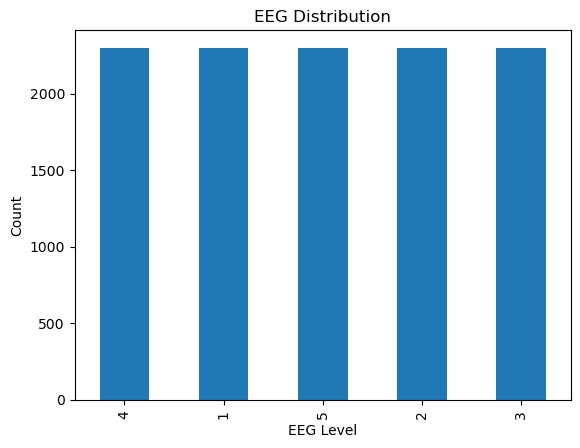

In [11]:
df['y'].value_counts().plot(kind='bar')
plt.title("EEG Distribution")
plt.xlabel("EEG Level")
plt.ylabel("Count")
plt.show()


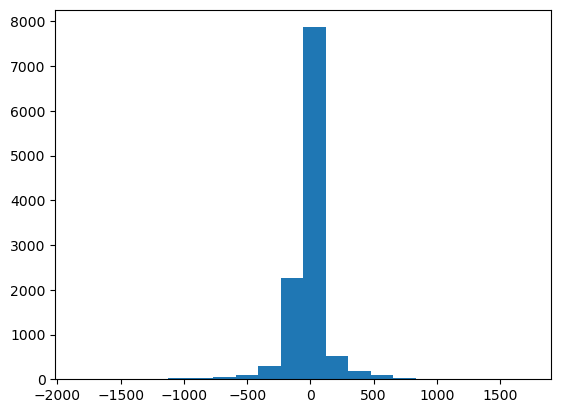

In [12]:
plt.hist(df['X1'], bins=20)
plt.show()


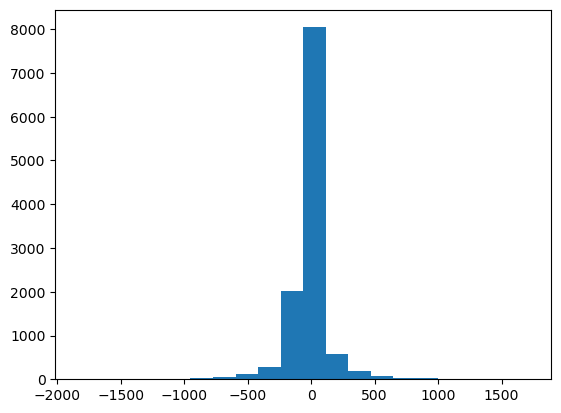

In [13]:
plt.hist(df['X2'], bins=20)

plt.show()


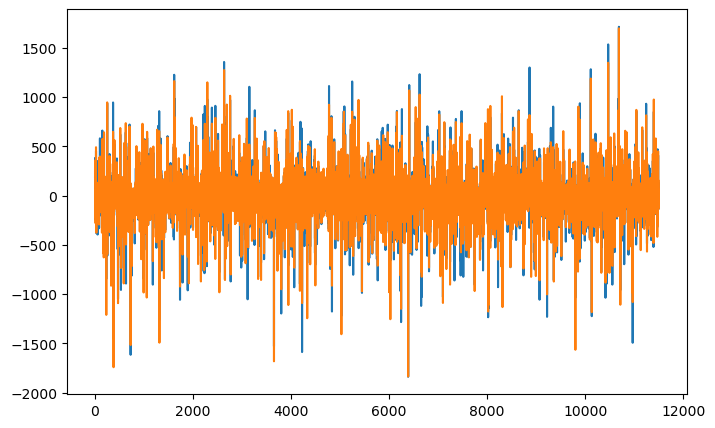

In [14]:
plt.figure(figsize=(8,5))
plt.plot(df['X2'], label='X2')
plt.plot(df['X3'], label='X3')
plt.show()


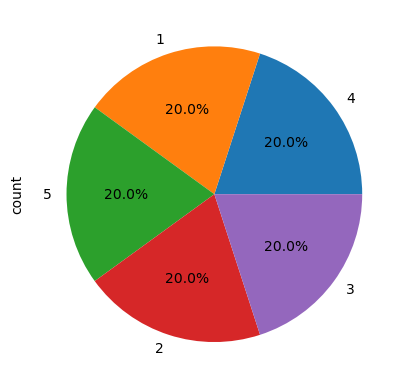

In [15]:
df['y'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()


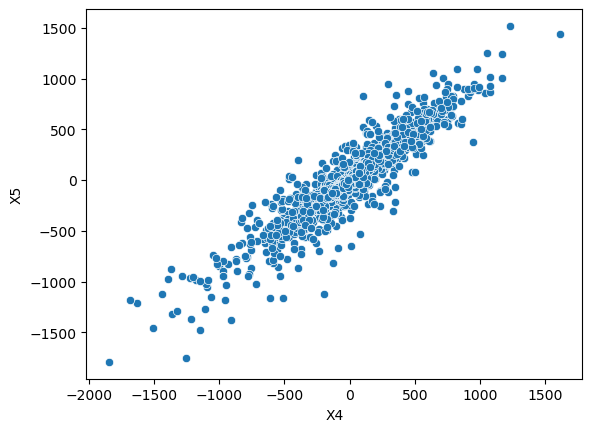

In [16]:
sns.scatterplot(x='X4', y='X5',  data=df)
plt.show()


In [17]:
df.dtypes

X1      int64
X2      int64
X3      int64
X4      int64
X5      int64
        ...  
X175    int64
X176    int64
X177    int64
X178    int64
y       int64
Length: 179, dtype: object

In [18]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='object', length=179)

In [19]:
X = df.drop('y',axis=1)
y = df['y']


In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11500, 178)
y shape: (11500,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [23]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)


In [24]:
scaler = StandardScaler()

In [25]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('svm', svm_model)
])


In [26]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])

In [27]:
y_pred = pipeline.predict(X_test)

In [28]:
svc_acc = accuracy_score(y_test, y_pred)
print("Accuracy:", svc_acc)


Accuracy: 0.5652173913043478


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.94      0.95      0.94       460
           2       0.39      0.19      0.26       460
           3       0.50      0.26      0.34       460
           4       0.83      0.53      0.64       460
           5       0.38      0.90      0.54       460

    accuracy                           0.57      2300
   macro avg       0.61      0.57      0.54      2300
weighted avg       0.61      0.57      0.54      2300



In [30]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[436  19   1   4   0]
 [ 23  87  79  10 261]
 [  6  71 120  17 246]
 [  1  37  23 242 157]
 [  0   8  17  20 415]]


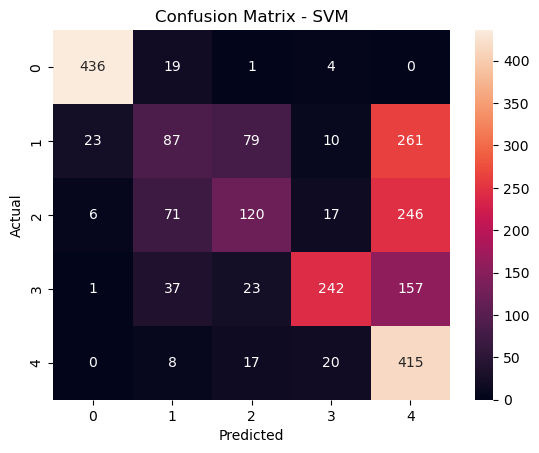

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)


In [34]:
rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [35]:
y_pred = rf_model.predict(X_test)


In [36]:
rf_acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.7204347826086956


In [37]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.93      0.97      0.95       460
           2       0.64      0.56      0.60       460
           3       0.61      0.56      0.58       460
           4       0.77      0.76      0.77       460
           5       0.64      0.74      0.69       460

    accuracy                           0.72      2300
   macro avg       0.72      0.72      0.72      2300
weighted avg       0.72      0.72      0.72      2300



In [38]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[448   7   0   5   0]
 [ 16 257 136   7  44]
 [ 15 113 259  28  45]
 [  1   4   1 351 103]
 [  0  22  32  64 342]]


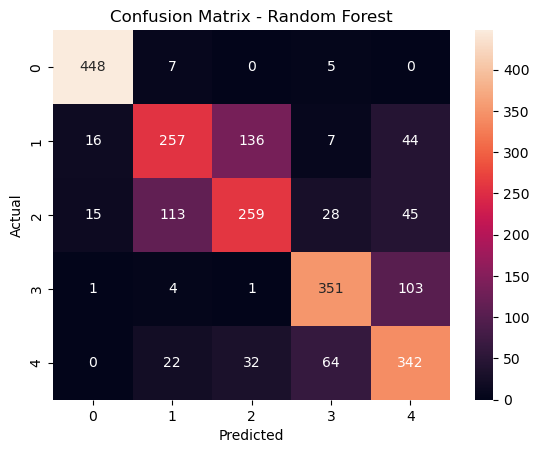

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [42]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', log_reg)
])


In [43]:
pipeline.fit(X_train, y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    random_state=42))])

In [44]:
y_pred = pipeline.predict(X_test)


In [45]:
lg_acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", lg_acc)


Logistic Regression Accuracy: 0.2591304347826087


In [46]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.36      0.36      0.36       460
           2       0.22      0.22      0.22       460
           3       0.22      0.14      0.17       460
           4       0.24      0.33      0.28       460
           5       0.25      0.24      0.25       460

    accuracy                           0.26      2300
   macro avg       0.26      0.26      0.25      2300
weighted avg       0.26      0.26      0.25      2300



In [47]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[167  75  63  84  71]
 [ 69 102  59 139  91]
 [ 71 103  64 142  80]
 [ 89  85  55 154  77]
 [ 74  96  48 133 109]]


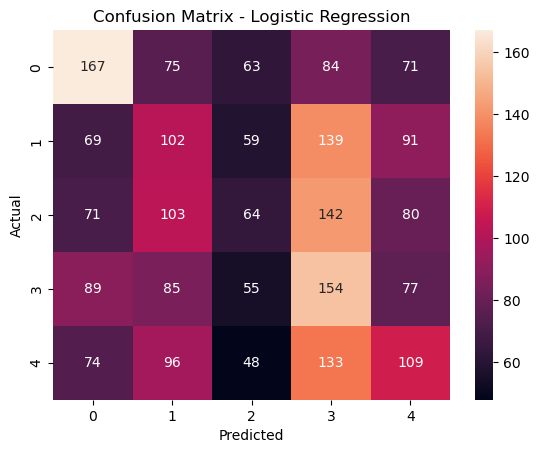

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [49]:
from sklearn.naive_bayes import GaussianNB

In [50]:
nb_model = GaussianNB()

In [51]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', nb_model)
])


In [52]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('nb', GaussianNB())])

In [53]:
y_pred = pipeline.predict(X_test)

In [54]:
nb_acc = accuracy_score(y_test, y_pred)
print("Naïve Bayes Accuracy:", nb_acc)


Naïve Bayes Accuracy: 0.44


In [55]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.91      0.83      0.87       460
           2       0.19      0.14      0.16       460
           3       0.30      0.19      0.24       460
           4       0.40      0.26      0.32       460
           5       0.37      0.78      0.50       460

    accuracy                           0.44      2300
   macro avg       0.44      0.44      0.42      2300
weighted avg       0.44      0.44      0.42      2300



In [56]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[381  78   0   1   0]
 [ 33  64  54  59 250]
 [  3  66  89  82 220]
 [  0 108 101 120 131]
 [  0  15  52  35 358]]


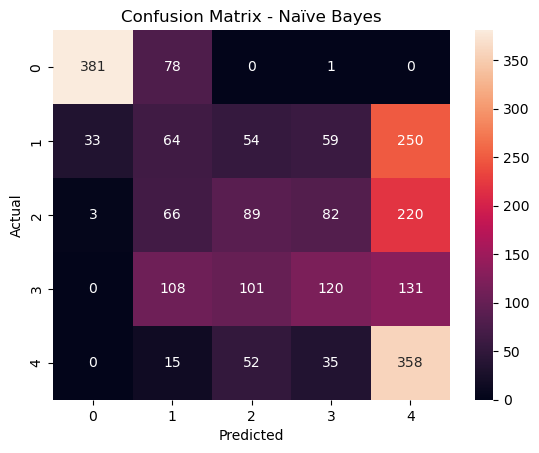

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Naïve Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [58]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,   
    weights='uniform',  
    metric='minkowski', 
    p=2      
)

In [60]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', knn_model)
])

In [61]:
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [62]:
y_pred_knn = pipeline_knn.predict(X_test)

In [63]:
knn_acc = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.4891304347826087


In [64]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           1       0.99      0.73      0.84       460
           2       0.37      0.64      0.47       460
           3       0.36      0.68      0.47       460
           4       0.90      0.30      0.45       460
           5       0.29      0.09      0.14       460

    accuracy                           0.49      2300
   macro avg       0.58      0.49      0.47      2300
weighted avg       0.58      0.49      0.47      2300



In [65]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm_knn)

Confusion Matrix:
 [[338  64  43  10   5]
 [  4 294 157   0   5]
 [  0 140 314   2   4]
 [  0 106 128 138  88]
 [  0 187 228   4  41]]


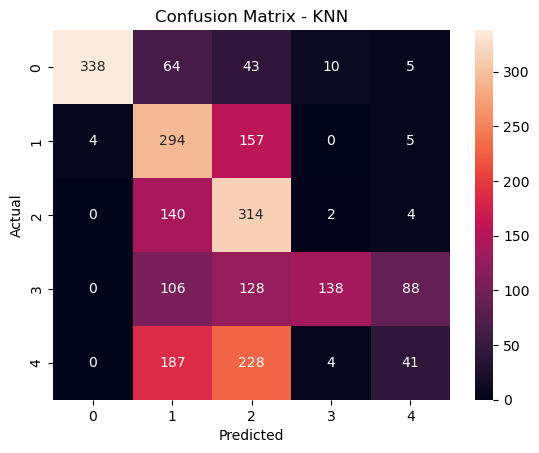

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [68]:
base_estimator = DecisionTreeClassifier(
    max_depth=1,  # Stump
    random_state=42
)

In [69]:
adaboost_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,   # Number of weak learners
    learning_rate=1.0, # Step size for weight update
    random_state=42
)

In [70]:
from sklearn.pipeline import Pipeline
pipeline_adaboost = Pipeline([
    ('scaler', StandardScaler()),  # Optional; trees don’t need scaling
    ('adaboost', adaboost_model)
])

In [71]:
pipeline_adaboost.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('adaboost',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=42),
                                    random_state=42))])

In [72]:
y_pred_ab = pipeline_adaboost.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
ab_acc = accuracy_score(y_test, y_pred_ab)
print("AdaBoost Accuracy:", ab_acc)

AdaBoost Accuracy: 0.44130434782608696


In [74]:
print(classification_report(y_test, y_pred_ab))

              precision    recall  f1-score   support

           1       0.83      0.90      0.87       460
           2       0.24      0.08      0.12       460
           3       0.31      0.09      0.14       460
           4       0.39      0.26      0.31       460
           5       0.33      0.87      0.48       460

    accuracy                           0.44      2300
   macro avg       0.42      0.44      0.38      2300
weighted avg       0.42      0.44      0.38      2300



In [75]:
cm_ab = confusion_matrix(y_test, y_pred_ab)
print("Confusion Matrix:\n", cm_ab)

Confusion Matrix:
 [[415  22   1  22   0]
 [ 41  37  25  56 301]
 [ 16  36  42  83 283]
 [ 27  55  43 120 215]
 [  0   6  26  27 401]]


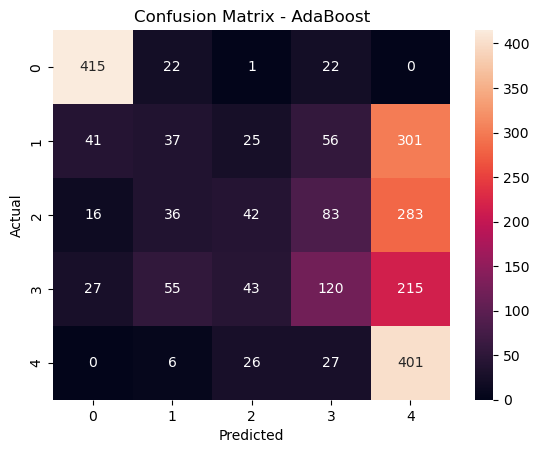

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_ab, annot=True, fmt='d')
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [77]:
from sklearn.ensemble import GradientBoostingClassifier

In [78]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,     # Number of boosting stages
    learning_rate=0.1,    # Shrinks contribution of each tree
    max_depth=3,          # Depth of individual trees
    random_state=42
)

In [79]:
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),   
    ('gb', gb_model)
])


In [80]:
pipeline_gb.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('gb', GradientBoostingClassifier(random_state=42))])

In [81]:
y_pred_gb = pipeline_gb.predict(X_test)

In [82]:
gb_acc = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 0.6191304347826087


In [83]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           1       0.94      0.92      0.93       460
           2       0.44      0.31      0.37       460
           3       0.44      0.49      0.46       460
           4       0.74      0.71      0.73       460
           5       0.53      0.66      0.59       460

    accuracy                           0.62      2300
   macro avg       0.62      0.62      0.62      2300
weighted avg       0.62      0.62      0.62      2300



In [84]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
print("Confusion Matrix:\n", cm_gb)

Confusion Matrix:
 [[424  14   8  14   0]
 [ 18 143 195  18  86]
 [ 10 121 224  25  80]
 [  0  12  20 328 100]
 [  0  33  66  56 305]]


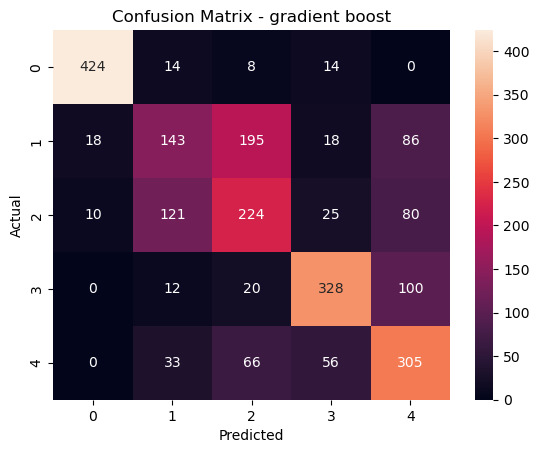

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_gb, annot=True, fmt='d')
plt.title("Confusion Matrix - gradient boost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [86]:
dt_model = DecisionTreeClassifier(
    criterion='gini',      # or 'entropy'
    max_depth=5,           # control overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [87]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [88]:
y_pred_dt = dt_model.predict(X_test)

In [89]:
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.3508695652173913


In [90]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           1       0.79      0.76      0.77       460
           2       0.00      0.00      0.00       460
           3       0.00      0.00      0.00       460
           4       0.00      0.00      0.00       460
           5       0.25      1.00      0.39       460

    accuracy                           0.35      2300
   macro avg       0.21      0.35      0.23      2300
weighted avg       0.21      0.35      0.23      2300



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [91]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", cm_dt)

Confusion Matrix:
 [[349   0   0   0 111]
 [ 34   0   0   0 426]
 [ 17   0   0   0 443]
 [ 39   0   0   0 421]
 [  2   0   0   0 458]]


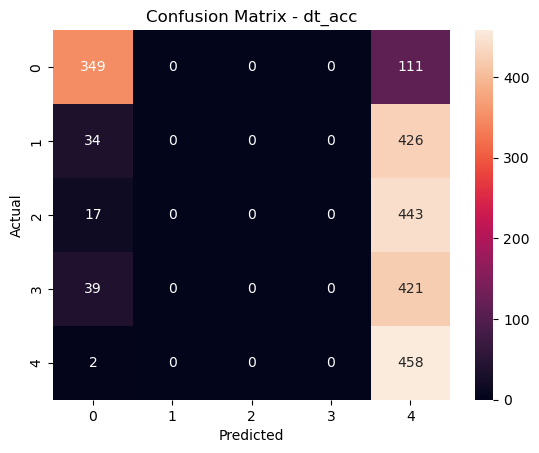

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Confusion Matrix - dt_acc")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

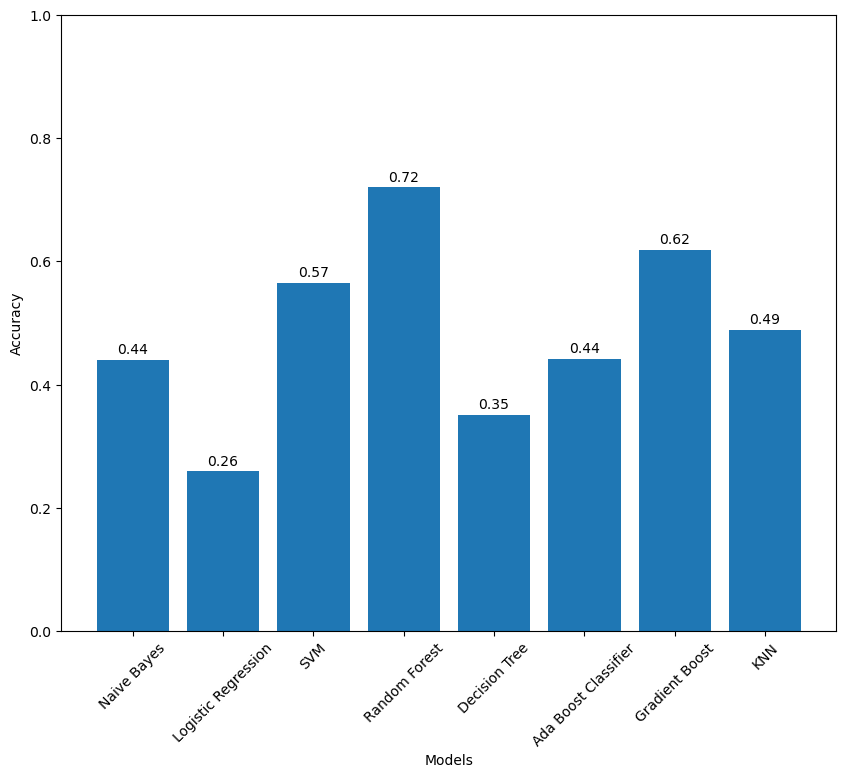

In [93]:
import matplotlib.pyplot as plt

models = [
    'Naive Bayes',
    'Logistic Regression',
    'SVM',
    'Random Forest',
    'Decision Tree',
    'Ada Boost Classifier',
    'Gradient Boost',
    'KNN',
    
]

accuracies = [
    nb_acc,
    lg_acc,
    svc_acc,
    rf_acc,
    dt_acc,
    ab_acc,
    gb_acc,
    knn_acc
]

plt.figure(figsize=(10,8))
plt.bar(models, accuracies)
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Accuracy")


for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


In [94]:
df['y'].unique()

array([4, 1, 5, 2, 3], dtype=int64)

In [96]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical


In [97]:
X = df.drop('y', axis=1).values
y = df['y'].values

# Convert labels from [1–5] → [0–4]
y = y - 1


In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [99]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [100]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [101]:
num_classes = len(np.unique(y))
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


In [103]:
model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                 input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))


C:\Users\pantech\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [104]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [105]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5374 - loss: 1.0406 - val_accuracy: 0.6168 - val_loss: 0.8200
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6344 - loss: 0.8245 - val_accuracy: 0.6766 - val_loss: 0.7256
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6647 - loss: 0.7412 - val_accuracy: 0.6967 - val_loss: 0.6612
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6829 - loss: 0.6960 - val_accuracy: 0.6739 - val_loss: 0.7067
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6990 - loss: 0.6584 - val_accuracy: 0.7043 - val_loss: 0.6226
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7143 - loss: 0.6195 - val_accuracy: 0.7071 - val_loss: 0.6503
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7253 - loss: 0.5928 - val_accuracy: 0.7293 - val_loss: 0.5775
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.7360 - loss: 0.5711 - val_acc

In [106]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7409 - loss: 1.1598
Test Accuracy: 0.7408695816993713


In [107]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) + 1  


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [108]:
model.save("cnn_model.h5")
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']